---
title: "Density Plots"
subtitle: "DS 2023 | Communicating with Data"
---

<img src="https://virginia.box.com/shared/static/18bic5a77gpd1011x47lj870elx38hgo.png" style="width:500px;"/>

## Overview

A density plot is something like a **continuous version of a histogram**. 

Like a histogram, it represents the **distribution of a continuous variable**. 

But instead of using binning and counting, it estimates **a probability density function** using more sophisticated methods, such as kernel estimation.

A density plot may be thought of as a special case of a line graph where the x axis represents an increasing numeric value, and the y axis represents an estimate or frequency. 

However, the density plot does not represent a trend. Instead, it is more like the function use case.

Like line graphs, they may also be rendered as area charts to show accumulation.

## Use Cases

Like histograms, density plots provide a quick way to inspect the **centrality and dispersion** of a distribution.

They allow you to inspect the shape of a distribution for **modality, skew, and kurtosis**.

They can also surface **outliers and mutliple populations**.

Density plots are **more opiniated** than histograms &mdash; they posit a **function** behind the data. 

Instead of showing counts, it shows the **denstity of data points** within a given range. 

Density plots are particularly useful for larger datasets.

## Creating a density plot from scratch

Density plots are construced using a method called **kernel density estimation** (KDE). 

This is why they are often called KDE plots, as in Pandas (see below).

The image below gives a good idea of how they are constructed.

For each data point, a gaussian distribution is generated. 

These are **the kernels**.

Then, these kernels are added up to produce the **resulting curve**.

In practice the algorithm may be more complicated &mdash; for example the parameters of the kernals may vary &mdash; but this is the essential idea.

![](images/kde-method.png)

To show how we can create one of these, let's use the dataset we used in our discussion of histograms, the `healthexp` dataset from Seaborn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
healthexp = sns.load_dataset('healthexp')
healthexp = healthexp.set_index(['Year', 'Country'])
healthexp.head()

Spending_USD  Life_Expectancy
Year Country                                     
1970 Germany             252.311             70.6
     France              192.143             72.2
     Great Britain       123.993             71.9
     Japan               150.437             72.0
     USA                 326.961             70.9

Let's specifically focus on the `Life_Expectancy` variable.

We pull out the series and call it `le_data`.

In [3]:
le_data = healthexp.Life_Expectancy

To generate the curve, we will use SciPy's `gaussian_kde` function.

In [4]:
from scipy.stats import gaussian_kde

Here we supply our data to the imported function to generate an object `kde`.

This object will be able to generate the curve.

In [5]:
kde = gaussian_kde(le_data)

To generate the curve, we need to know what values our x axis will have.

That is, we need to specify what part of the domain of `Life_Expectancy` we want to project onto the x axis.

Here we define it in terms of the minimum and maximum values of our input data, plus a little padding &mdash; $5$ years on either side.

In [6]:
x = np.linspace(le_data.min() - 5, le_data.max() + 5, 100)

Now we can generate $y$ from $x$, i.e. $f(x)$.

In [7]:
y = kde(x)

With $x$ and $y$ in hand, we can just plot the data as a line.

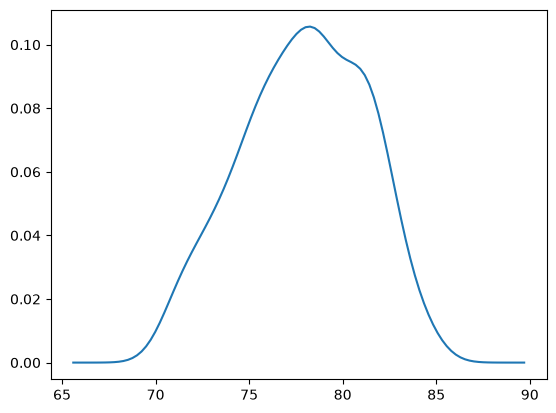

In [8]:
plt.plot(x, y)
plt.show()

This is density plot.

## Area under curve

An important property of a density plot is that the area under its curve must sum up to $1$.

This is because it represents all of the probability in the function.

To verify this, we can use NumPy's `trapezoid` function to estimate the area.

In [9]:
auc = np.trapezoid(y, x).round(2)
auc

np.float64(1.0)

And, indeed, it turns out to be $1$.

> [!NOTE]
>
> This means that, in effect, we have produced a **probability density function**, or PDF, from our data.

## Using Pandas KDE method

Now let's have Pandas create the plot.

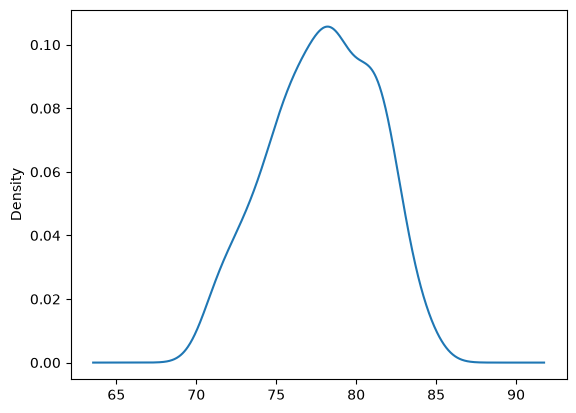

In [10]:
healthexp.Life_Expectancy.plot.kde()
plt.show()

It is basically identical to the one we created above.

This is because Pandas us using `gaussian_kde` under the hood.

Notice how it is a smoothed version of the histogram.

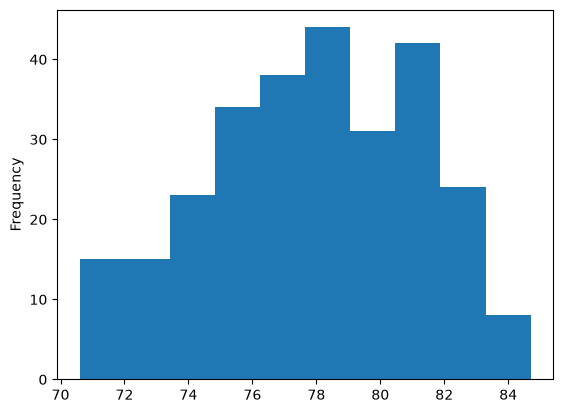

In [11]:
healthexp.Life_Expectancy.plot.hist()
plt.show()

## How to read a density plot

To understand how to read a density plot, let's compare it to the histogram.

Wheras the y axis of a histogram is a **count** (aka frequency), the y axis of a density plot is, as the name implies, a **density**.

A density is a _proportion_ of the data per unit of the x axis. 

### An example

In our example, since `Life_Expectancy` is measured in years, its density is a proportion per year.

In the plot below, the area of the region under the curve between $70$ and $71$ corresponds to the probability of a `Life_Expectancy` value to be $70$.

That is, a recorded value of $70$ means the true value was in $[70, 71)$. 

So $P(recorded = 70) ≈ area$ from $70$ to $71$.

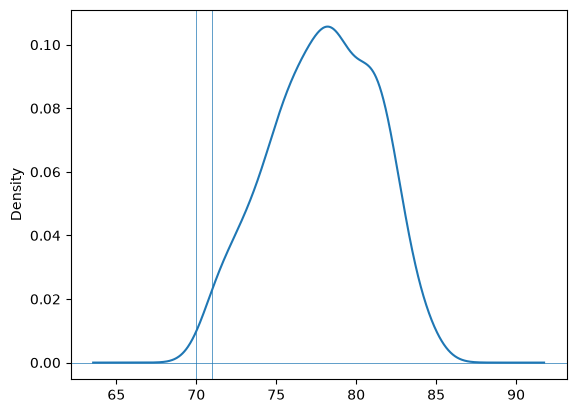

In [12]:
ax = healthexp.Life_Expectancy.plot.kde()
ax.axvline(70, lw=.5)
ax.axvline(71, lw=.5)
ax.axhline(0, lw=.5)
plt.show()

If we wanted to get the actual area corresponding to this span, we could compute it using the SciPy and NumPy functions we used above.

In [14]:
age_span_kde = gaussian_kde(healthexp.Life_Expectancy)
age_span_x = np.linspace(70, 71)
age_span_y = age_span_kde(age_span_x)
round(np.trapezoid(age_span_y, age_span_x), 2)

np.float64(0.02)

We find that $P(recorded = 70) ≈ .02$, or $2\%$ of the observations have an age value of $70$.

So, instead of reading the **height**, as you would in a histogram, you read the **area**.

### Another example

To reinforce this idea, consider that the curve above peaks at about $0.106$ near $78.2$ years.

The number $0.106$ is not the proportion of observations at $78.2$.

A proportion requires a width.

The area under the curve between $78$ and $81$ years is $0.298$, so about $30\%$ of the observations fall in that interval.

Counted directly, $29.2\%$ of them do.

> [!IMPORTANT]
>
> So, the height of a curve tells you **how concentrated the data is**, not how much
of it there is.
>
> A narrow distribution has to be tall and a wide one has to be low.

### Comparing heights

Note that y axis values (heights) cannot be compared across variables.

- The curve for `Life_Expectancy` peaks at about $0.106$ per year.

- The curve for `Spending_USD` peaks at about $0.0002$ per dollar.

Both describe the same $274$ observations and both enclose an area of $1$.

The actual domain projects onto the y axis is a function of the **units** for the data: 

- Spending is spread across thousands of dollars, so its density is correspondingly small.

## Comparing two density plots

To compare density plots for different variables, you want to compare **shapes**, not magnitudes.

The domains of the x axes and ranges of the y axes vary among variables for density plots, as explained above.

So, in the example below, we turn off sharing by the x and y axes. 

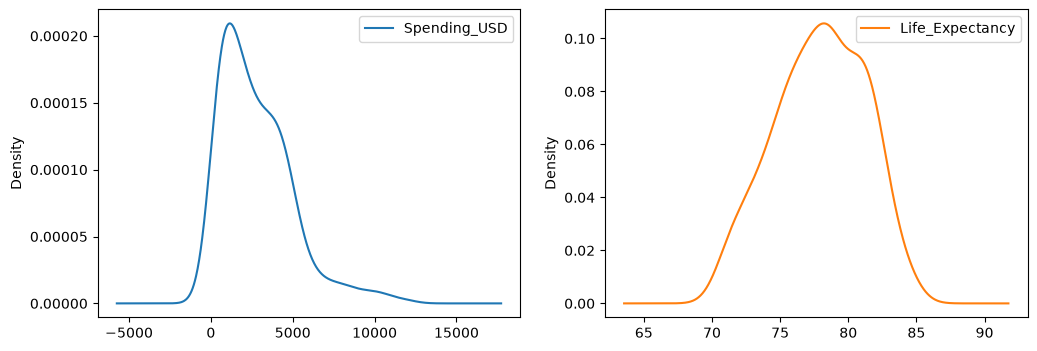

In [15]:
healthexp.plot.kde(subplots=True, layout=(1,2), sharex=False, figsize=(12,4))
plt.show()

Notice that Pandas renders subbpots as if each plot comes from the same domain, as would be the case this were a wide table, where each plot represents a subset of a single variable. 

By convention, Pandas uses color to differentiate the plots and the legend to label them. 

In this example, each plot represents a different variable. 

In such cases, you may want to change the aesthetics, so that each plot is designated by a title, not a legend, and that the colors of the two plots are the same.

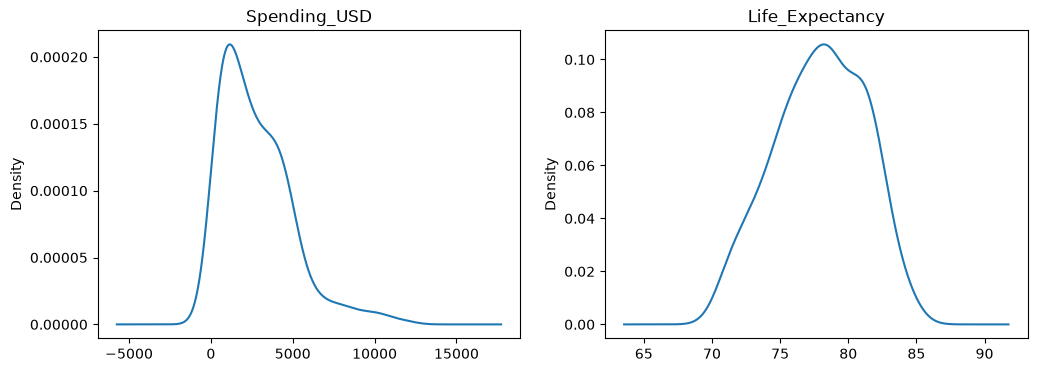

In [20]:
healthexp.plot.kde(subplots=True, layout=(1,2), sharex=False, figsize=(12,4), 
              color='tab:blue', title=[col for col in healthexp.columns], legend=False)
plt.show()

Finally, using a more complex pattern, you can overlay them.

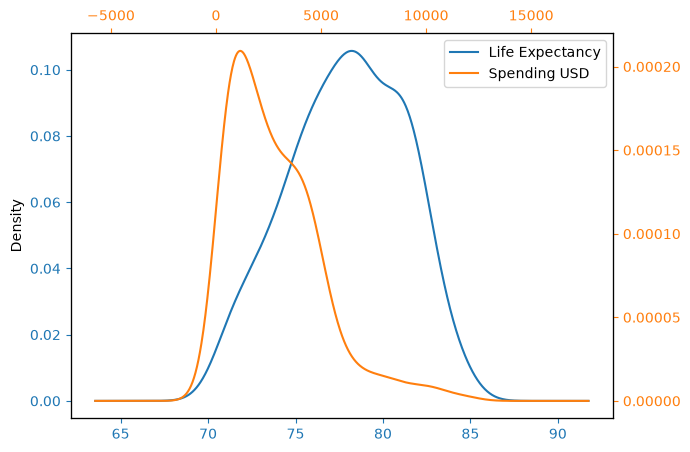

In [22]:
fig, ax1 = plt.subplots(figsize=(7,5))


# A bit of a hack that you have to remember
# since we are twinning both the x and y axes
ax_right = ax1.twinx()
ax2 = ax_right.twiny()

healthexp['Life_Expectancy'].plot.kde(ax=ax1, color='tab:blue', label='Life Expectancy', legend=False)
healthexp['Spending_USD'].plot.kde(ax=ax2, color='tab:orange', label='Spending USD', legend=False)

# Pandas re-enables ax2's y-axis on the left, so we hide it and use ax_right instead
ax2.yaxis.set_visible(False)

# Align the colors of the ticks and spines for readability
ax1.tick_params(axis='x', colors='tab:blue')
ax1.tick_params(axis='y', colors='tab:blue')
ax2.tick_params(axis='x', colors='tab:orange')
ax_right.tick_params(axis='y', colors='tab:orange')

# Combine the legends from both independent spaces
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.show()

## Showing multiple groups

If we want to show how the density plots of countries differ, we first create a wide table that projects the domain of `country` onto axis 1. 

In this table, each column represents a subset of the variable `country`.

In [23]:
life_exp_wide = healthexp.Life_Expectancy.unstack()
life_exp_wide.head()

Country,Canada,France,Germany,Great Britain,Japan,USA
Year,,,,,,
1970,NaN,72.2,70.6,71.9,72.0,70.9
1971,72.8,NaN,70.8,71.9,72.9,71.2
1972,NaN,NaN,71.0,NaN,73.2,71.2
1973,NaN,NaN,71.3,NaN,73.4,71.4
1974,NaN,NaN,71.5,NaN,73.7,72.0


Now we can plot it and Pandas will treat each column as a plot line.

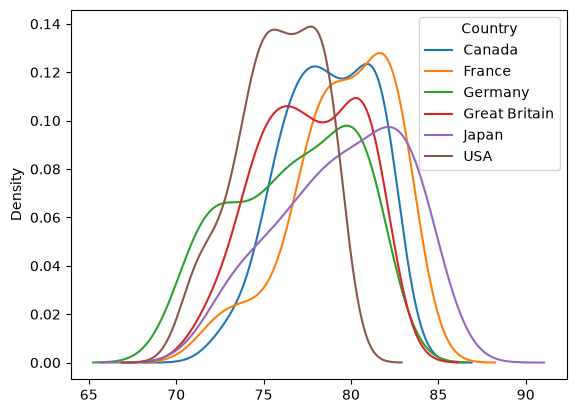

In [24]:
life_exp_wide.plot.kde()
plt.show()

You can color in the area under each curve by iterating through each line and applying the `fill_between` method.

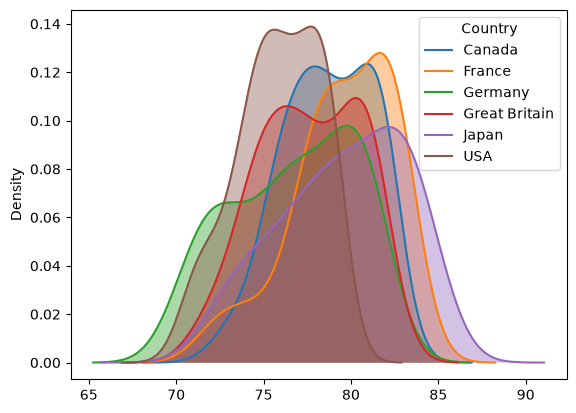

In [25]:
ax = life_exp_wide.plot.kde()

# Iterate through the individual lines
for line in ax.lines:
    ax.fill_between(line.get_xdata(), line.get_ydata(), alpha=0.4)

plt.show()

> [!WARNING] The result looks something like an unstacked area chart.
>
> But in this case, you can't unstack the lines.
>
> This is because it doesn't make sense to add densities.

You also show them as subplots.

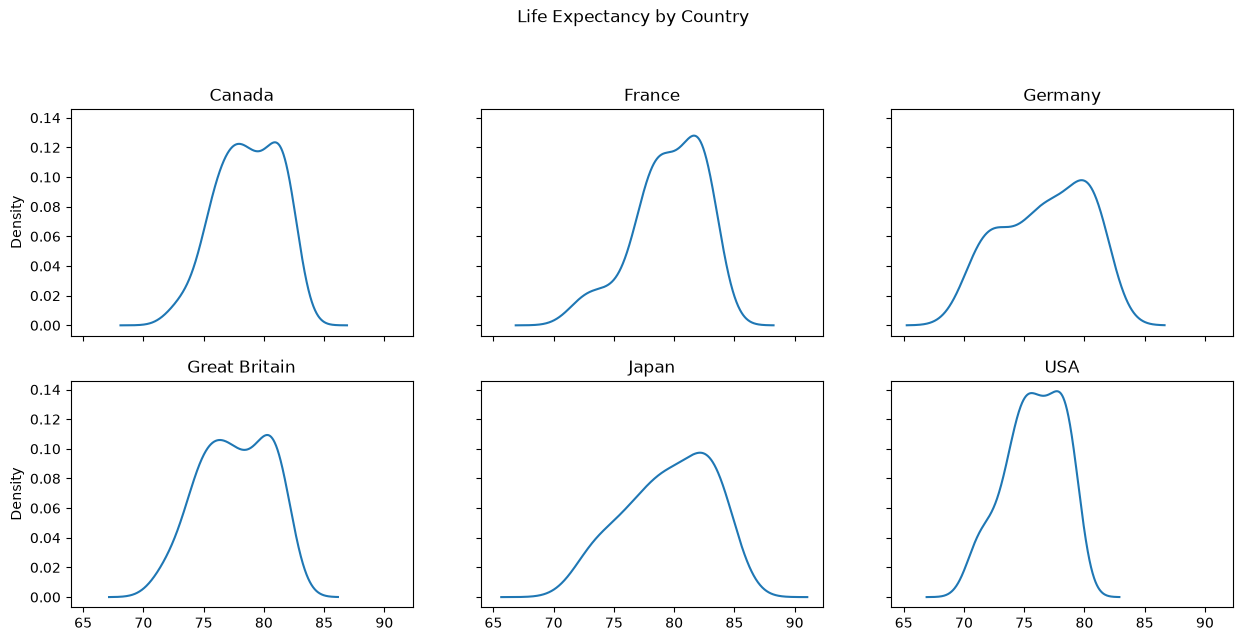

In [26]:
life_exp_wide.plot.kde(subplots=True, figsize=(15, 10), layout=(3,3), sharey=True, 
                       title=list(life_exp_wide.columns), legend=False, color='tab:blue')
plt.suptitle("Life Expectancy by Country")
plt.show()

## Interpreting the results

Looking at the life expectancy variable condidtion by country, what we can learn from these plots?

In particular, what does the height and shape of the plot for USA tell us?

## Using Seaborn

Seaborn's version of density plots has a simple argument to achieve the same effect.

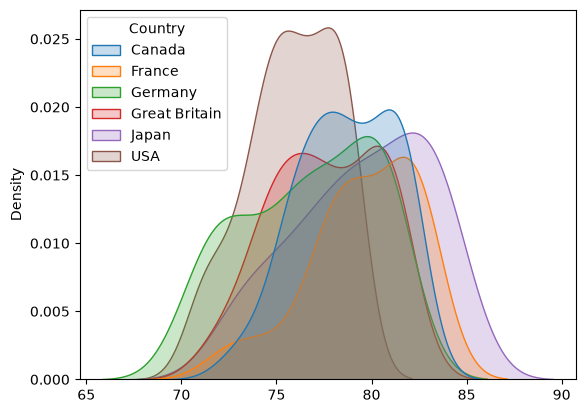

In [27]:
sns.kdeplot(life_exp_wide, fill=True)
plt.show()

Seaborn's version also allows you to by-pass having to pivot the tidy table. 

Instead of first setting the columns to `Country` in the pivot function, you can just set the `hue` (i.e. color) to `Country`.

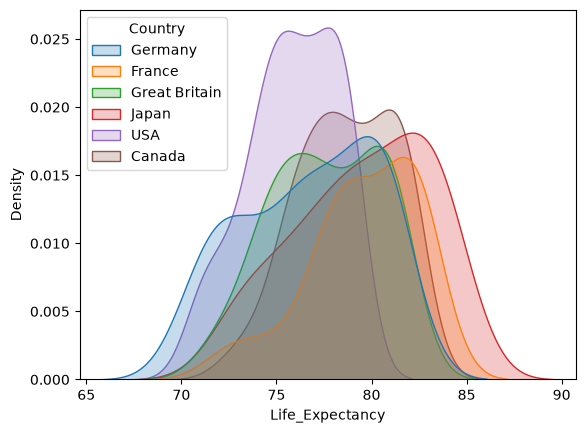

In [28]:
sns.kdeplot(healthexp, x='Life_Expectancy', hue='Country', fill=True)
plt.show()

> [!CAUTION] Although by-passing the need to widen the table is convenient, it also violates the design pattern of shaping your data as part of the visualization pipeline.

## Combining histograms and density plots

Sometimes we want to hedge our bets and show both histograms and density plots at the same time.

One way to do this is to set `density = True` on the histogram and then plot both an the same axes object.

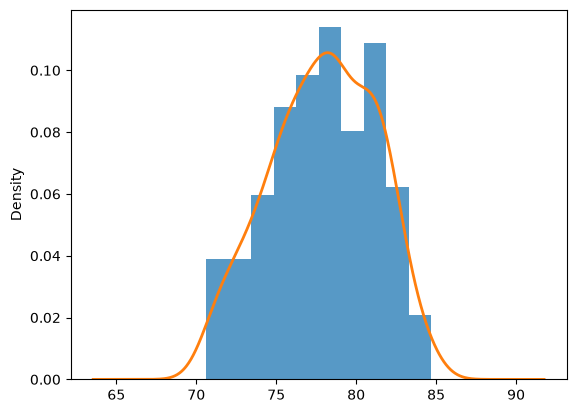

In [29]:
healthexp.Life_Expectancy.plot.hist(density=True, alpha=.75)
healthexp.Life_Expectancy.plot.kde(lw=2)
plt.show()

Another pattern is to use `ax.twinx()`, as we did in our lesson on Line Graphs.

This preserves the y axis domains of both plots.

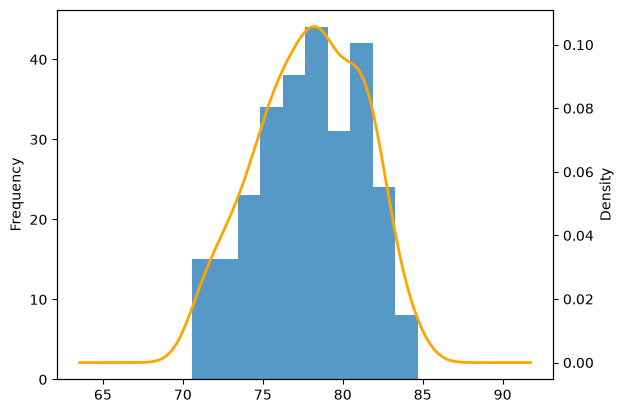

In [30]:
ax1 = healthexp.Life_Expectancy.plot.hist(alpha=.75)
ax2 = ax1.twinx()
healthexp.Life_Expectancy.plot.kde(ax=ax2, color='orange', lw=2)
plt.show()

Note, however, the misalignment of the two axes. 

Even though they represent different domains, they should align at $0$.

Because density plots can be negative, the plotting function left some room for that.

To align the two axes, we use `ylim` to force the y axis of the second plot to be use $0$ as its bottom value.

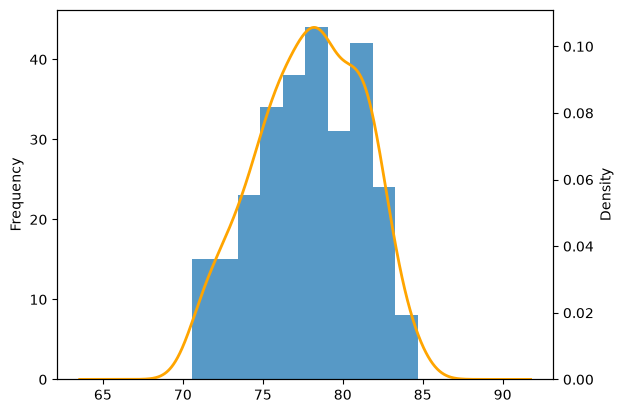

In [31]:
ax1 = healthexp.Life_Expectancy.plot.hist(alpha=.75)
ax2 = ax1.twinx()
healthexp.Life_Expectancy.plot.kde(ax=ax2, color='orange', lw=2, ylim=(0, None))
plt.show()

## Choosing a bandwidth

If a density plot is a smoothed histogram, the obvious question is how much smoothing to apply.

This is analogous to choosing the number of bins in a histogram.

This is governed by the **bandwidth**, which sets the width of each of the gaussian kernels.

- A **narrow** bandwidth makes each kernel a thin spike, and the resulting curve follows the data closely.

- A **wide** bandwidth makes each kernel a broad hill, and the curve flattens toward a single smooth mound.

Pandas exposes this parameter as the `bw_method` argument, which it hands off to SciPy.

> [!NOTE]
>
> Left alone, SciPy applies **Scott's rule**, which scales the bandwidth by $n^{-1/5}$.
>
> For our $274$ observations this works out to about $0.33$.

Below we draw the same variable three times, over a histogram of the same data for reference.

In [32]:
bandwidths = {
    "Narrow": .15,
    "Scott's rule": .33,
    "Wide": .1
}

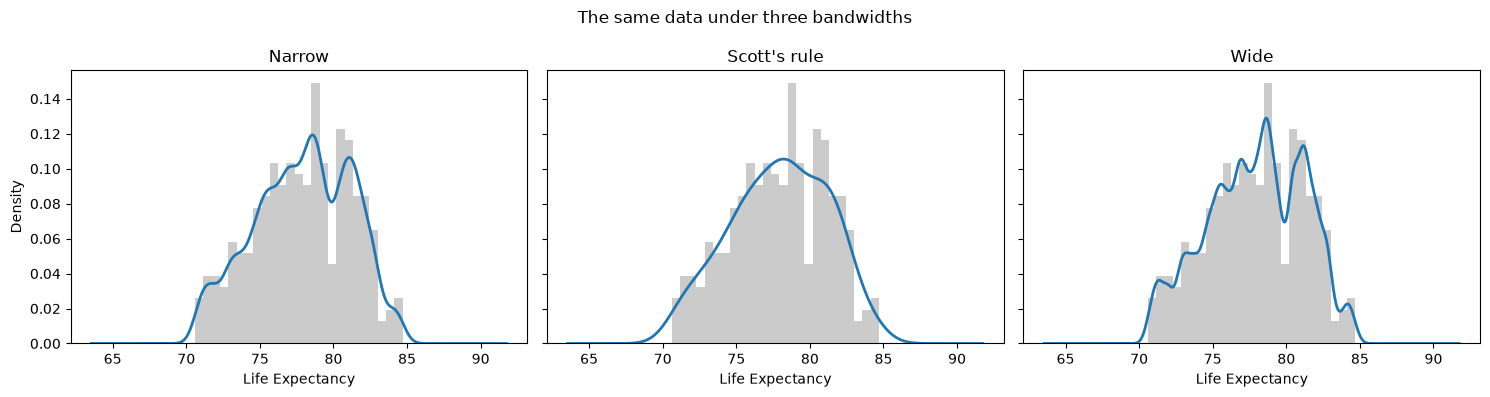

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for i, bw in enumerate(bandwidths):
    # PLot the histogram
    healthexp.Life_Expectancy.plot.hist(ax=axes[i], bins=25, density=True, alpha=.4, color='tab:gray')
    # Plot the KDE
    healthexp.Life_Expectancy.plot.kde(ax=axes[i], bw_method=bandwidths[bw], color='tab:blue', lw=2)
    # Name things
    axes[i].set_title(bw)
    axes[i].set_xlabel('Life Expectancy')
    
plt.suptitle('The same data under three bandwidths')
plt.tight_layout()
plt.show()

The left panel describes two populations. 

The right panel describes one broad population.

> [!WARNING]
>
> The bandwidth is an argument you are making, not a default you are accepting.
>
> - An **over-smoothed** curve can **erase** a mode that is really there.
>
> - An **under-smoothed** curve can **manufacture** modes out of sampling noise.
>
> So, when you use a density plot as the basis of a claim about modality, report the bandwidth.

Notice also that the wide curve assigns density below $70$ and above $85$, although no country in the dataset falls outside the range $70.6$ to $84.7$.

That is a general property of the method, and the subject of our last section.

## When density plots mislead

The smoothness of a density plot is itself a claim about the world.

It asserts that the underlying variable is continuous, and that the space between the observations you happen to have is meaningful.

Where that assertion is false, the density plot misleads in ways that the histogram does not.

### Small samples

With few observations, the curve is mostly bandwidth and very little data.

We said above that density plots are particularly useful for larger datasets; the converse is worth saying too.

Given a dozen points, each kernel becomes a visible bump, and a reader will take those bumps for modes.

A histogram, or better a strip plot, is more honest at that size, because it shows the reader how little data there is.

### Discrete and categorical data

A density plot of a die roll, a star rating, or a count of children per household draws a smooth curve through values that cannot occur.

The curve will cheerfully assign density to $2.4$ children.

### Bounded variables

Kernel density estimation knows nothing about the limits of a variable.

A test score out of $100$, a proportion, an age, a duration &mdash; each has a hard boundary, and kernels placed near that boundary spill across it.

This is called **boundary bias**, and it costs you twice: density is assigned to impossible values, and the density at the boundary itself is underestimated, since there are no observations on the far side to balance the estimate.

> [!TIP]
>
> Before deciding to use a density plot, ask whether the variable is continuous, and whether it is unbounded across the range you mean to plot.
>
> If the answer to either question is no, a histogram is usually the safer instrument.

To see how much boundary bias affects the example above, consider that we might have applied SciPy's `gaussian_kde` function directly to our dataset.

This produces a plot where the tails of the curve are removed.

Although we will not measure it here, you can see that there is a significant amount of probability mass that has been lost.

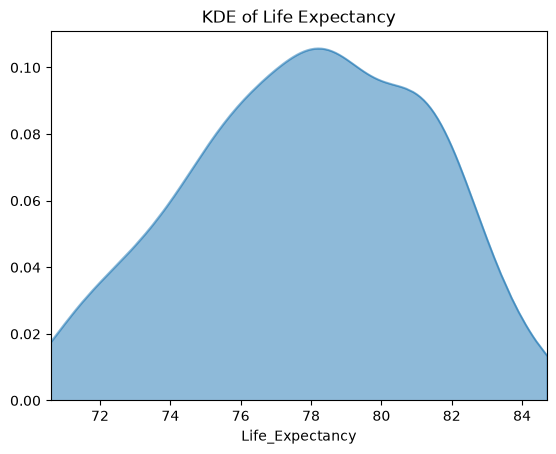

In [34]:
healthexp['le_kde'] = kde(healthexp['Life_Expectancy'].values)
ax = healthexp.sort_values('Life_Expectancy').plot.area(
    x='Life_Expectancy', y='le_kde', alpha=.5, 
    ylim=(0, None),
    xlim=(healthexp['Life_Expectancy'].min(), healthexp['Life_Expectancy'].max()),
    legend=False,
    title="KDE of Life Expectancy"
)
plt.show()